## Module 2 : Finding Neutral Atom Qubit Gates
### Exercise 2-4 : CZ-gate realization with Time-Optimal Gates
Problem Unsolved : 
- the meaning of populations in FIG.3.

In [1]:
%reload_ext autoreload
%autoreload 2

from Default_TQCONFIG_for_CZ_GATE_TO import *

### `Test with `$|01\rangle$ ` as initial state`
#### Initial state & Monitered Operators

In [37]:
# initial state
psi0 = two_atom_fock_states[0][1]  # |1,1>

# list of wanted operators 
# Note : ground state is the initial state, not always |0,0>
# Pg : one atom ground state : |0><0| ⊗ I + I ⊗ |0><0|
# Pg = tensor(state0 * state0.dag(), Qobj(np.eye(4))) + tensor(Qobj(np.eye(4)), state0 * state0.dag())
Pg = psi0 * psi0.dag()
# Pr : one atom Rydberg state : I ⊗ |r><r|
Pr = tensor(Qobj(np.eye(4)), stater * stater.dag())
# Pd : occupation of level |d> : I ⊗ |d><d|
Pd = tensor(Qobj(np.eye(4)), stated * stated.dag())
# Prr : double excited Rydberg state : |r,r><r,r|
P_rr = two_atom_fock_states[2][2] * two_atom_fock_states[2][2].dag()


# Pgg : two atom ground state : |0,0><0,0|
P_gg = psi0 * psi0.dag()
# P_gr : single excited Rydberg state with another atom in ground state : |r,0><r,0| + |r,1><r,1| + |0,r><0,r| + |1,r><1,r|
P_gr = two_atom_fock_states[2][0] * two_atom_fock_states[2][0].dag() \
      + two_atom_fock_states[2][1] * two_atom_fock_states[2][1].dag() \
      + two_atom_fock_states[0][2] * two_atom_fock_states[0][2].dag() \
      + two_atom_fock_states[1][2] * two_atom_fock_states[1][2].dag()

expect_op_list = [
  P_gg,
  P_gr,
  Pd,
  P_rr,
  Pg,
  Pr,
]

In [38]:
# construct the total Hamiltonian
Htotal, collapse_list = construct_TD_TAHam(atom0_ham_params, atom1_ham_params, 
                                           lindblad_params, lindblad_params, Rydberg_B)

# simulate the dynamics
result = mesolve(Htotal, psi0, tlist, collapse_list, expect_op_list, 
                 options={"store_final_state": 1, "store_states": 0})

d:\anaconda3\envs\my_qiskit\Lib\site-packages\qutip\solver\solver_base.py:583: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


#### Plot the Pulse Shape

<Axes: xlabel='Time ($\\mu$s)', ylabel='Amplitude (MHz)'>

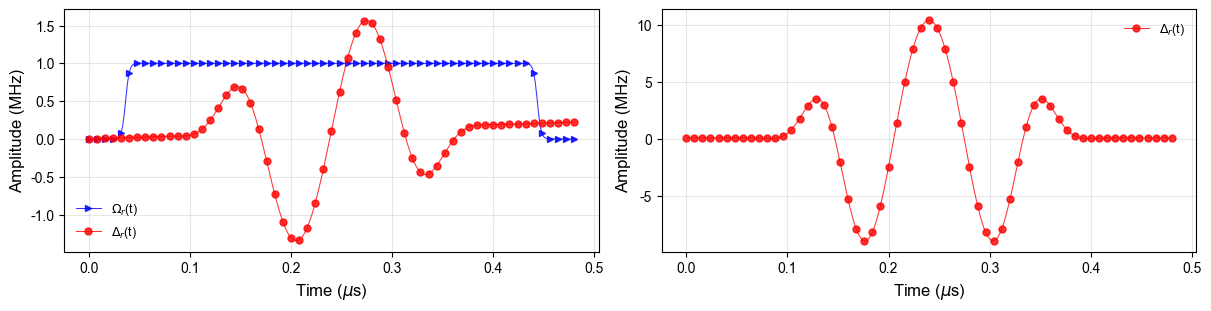

In [39]:
plotting_styles["Omega_r_pulse"]["markevery"] = 5
plotting_styles["Delta_r_pulse"]["markevery"] = 5
plt.rcParams.update(plt_config)

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharex=True, sharey=False, constrained_layout=True)
axes = axes.ravel()
# Plot the pulse shapes
pulse_dict = {
  'Omega_r': {'data': time_optimal_pulse_Omega_r, 'args': Omega_r_pulse_args, 
              'label': r'$\Omega_r$(t)', 'style': 'Omega_r_pulse', 'normalize_factor': amp_Omega_r},
  'Delta_r': {'data': time_optimal_pulse_phase_profile, 'args': Delta_r_pulse_args, 
              'label': r'$\Delta_r$(t)', 'style': 'Delta_r_pulse', 'normalize_factor': 1.0}
}

plot_pulse_shapes(
  ax = axes[0],
  tlist = tlist,
  pulse_dict = pulse_dict,
  title = None,
  xlabel = r"Time ($\mu$s)",
  ylabel = "Amplitude (MHz)",
  normalize_2pi = False,  # 使用每个脉冲自己的 normalize_factor
  ylim = None,
  grid_alpha = 0.3,
  # legend_config = legend_styles['compact'],
)

# Plot the pulse shapes of Delta_r
pulse_dict = {
  'Delta_r': {'data': time_optimal_pulse_Delta_r, 'args': Delta_r_pulse_args, 
              'label': r'$\Delta_r$(t)', 'style': 'Delta_r_pulse', 'normalize_factor': 2 * np.pi}
}

plot_pulse_shapes(
  ax = axes[1],
  tlist = tlist,
  pulse_dict = pulse_dict,
  title = None,
  xlabel = r"Time ($\mu$s)",
  ylabel = "Amplitude (MHz)",
  normalize_2pi = False,  # 使用每个脉冲自己的 normalize_factor
  ylim = None,
  grid_alpha = 0.3,
  # legend_config = legend_styles['compact'],
)
  

<Axes: title={'center': 'Rydberg gate simulation with time-optimal pulse'}, xlabel='Time ($\\mu$s)', ylabel='Population'>

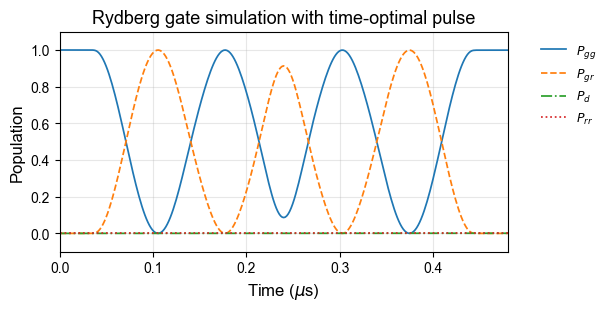

In [40]:
fig, ax = plt.subplots(figsize=(6, 3), sharex=True, sharey=False, constrained_layout=True)

# Plot the population evolution
pop_list = [result.expect[0], result.expect[1], result.expect[2], result.expect[3]]
legend_list = [r"$P_{gg}$", r"$P_{gr}$", r"$P_d$", r"$P_{rr}$"]

plot_population_evolution(
  ax = ax,
  tlist = tlist,
  pop_list = pop_list,
  legend_list = legend_list,
  plot_pulse = False,
  pulse_dict = {},
  title = r"Rydberg gate simulation with time-optimal pulse",
  xlabel = r"Time ($\mu$s)",
  ylabel = "Population",
  log_scale = False,
  xlim = None,
  ylim = None,
  grid_alpha = 0.3,
  show_legend = True,
  plotting_style_list = None,
)

### `Test with `$|11\rangle$ ` as initial state`

In [41]:
# initial state
psi0 = two_atom_fock_states[1][1]  # |1,1>

# list of wanted operators 
# Note : ground state is the initial state, not always |0,0>
# Pg : one atom ground state : |0><0| ⊗ I + I ⊗ |0><0|
# Pg = tensor(state0 * state0.dag(), Qobj(np.eye(4))) + tensor(Qobj(np.eye(4)), state0 * state0.dag())
Pg = psi0 * psi0.dag()
# Pr : one atom Rydberg state : |r><r| ⊗ I + I ⊗ |r><r|
Pr = tensor(stater * stater.dag(), Qobj(np.eye(4))) + tensor(Qobj(np.eye(4)), stater * stater.dag())
# Pd : occupation of level |d> : I ⊗ |d><d|
Pd = tensor(Qobj(np.eye(4)), stated * stated.dag()) + tensor(stated * stated.dag(), Qobj(np.eye(4)))
# Prr : double Rydberg state : |r,r><r,r|
P_rr = two_atom_fock_states[2][2] * two_atom_fock_states[2][2].dag()

# Pgg : two atom ground state : |0,0><0,0|
P_gg = psi0 * psi0.dag()
# P_gr : single excited Rydberg state with another atom in ground state : |r,0><r,0| + |r,1><r,1| + |0,r><0,r| + |1,r><1,r|
P_gr = two_atom_fock_states[2][0] * two_atom_fock_states[2][0].dag() \
      + two_atom_fock_states[2][1] * two_atom_fock_states[2][1].dag() \
      + two_atom_fock_states[0][2] * two_atom_fock_states[0][2].dag() \
      + two_atom_fock_states[1][2] * two_atom_fock_states[1][2].dag()

expect_op_list = [
  P_gg,
  P_gr,
  Pd,
  P_rr,
  Pg,
  Pr,
]

In [42]:
# construct the total Hamiltonian
Htotal, collapse_list = construct_TD_TAHam(atom0_ham_params, atom1_ham_params, 
                                           lindblad_params, lindblad_params, Rydberg_B)

# simulate the dynamics
result = mesolve(Htotal, psi0, tlist, collapse_list, expect_op_list, 
                 options={"store_final_state": 1, "store_states": 0})

<Axes: title={'center': 'Rydberg gate simulation with time-optimal pulse'}, xlabel='Time ($\\mu$s)', ylabel='Population'>

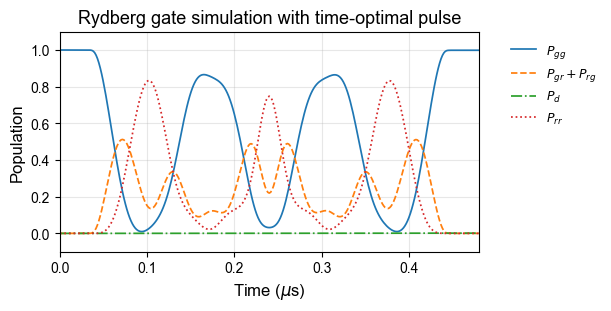

In [44]:
fig, ax = plt.subplots(figsize=(6, 3), sharex=True, sharey=False, constrained_layout=True)
  
# Plot the population evolution
pop_list = [result.expect[0], result.expect[1], result.expect[2], result.expect[3]]
legend_list = [r"$P_{gg}$", r"$P_{gr} + P_{rg}$", r"$P_d$", r"$P_{rr}$"]

plot_population_evolution(
  ax = ax,
  tlist = tlist,
  pop_list = pop_list,
  legend_list = legend_list,
  plot_pulse = False,
  pulse_dict = {},
  title = r"Rydberg gate simulation with time-optimal pulse",
  xlabel = r"Time ($\mu$s)",
  ylabel = "Population",
  log_scale = False,
  xlim = None,
  ylim = None,
  grid_alpha = 0.3,
  show_legend = True,
  plotting_style_list = None,
)


## `Calculate Gate Fidelity`

In [18]:
# initial state list for gate fidelity computation
psi0_list = make_initial_list_for_gate_fidelity(num_qubits = 2, dim_atom = 4)
qs0_list = make_initial_list_for_gate_fidelity(num_qubits = 2, dim_atom = 2)

# compute the state fidelities
state_fidelity_list, _ = compute_state_fidelity(
  qs0_list,
  target_gate, 
  Htotal, 
  collapse_list, 
  tlist,
  psi0_list=psi0_list,
  comp_indices=comp_indices,
  expect_list=None
)

# compute different types of gate fidelities
fidelity_mixed, fidelity_geom, fidelity_arith = compute_gate_fidelity_mixed(
  state_fidelity_list, dim_qubits, True
)

print(f"Gate Fidelity (Mixed State) : {fidelity_mixed:.6f}")
print(f"Gate Fidelity (Geometric) : {fidelity_geom:.6f}")

Gate Fidelity (Mixed State) : 0.999161
Gate Fidelity (Geometric) : 0.998307


d:\anaconda3\envs\my_qiskit\Lib\site-packages\qutip\core\data\expm.py:139: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
